# Exploring the OBIS SDM STAC catalogue

Since version 2, the MPA Europe SDMs are organized in a [STAC](https://stacspec.org/) (SpatioTemporal Asset Catalog) catalogue, stored at `s3://obis-maps/sdm/stac`. The easiest way to browse it interactively is through the [STAC browser](https://radiantearth.github.io/stac-browser/#/external/obis-maps.s3.us-east-1.amazonaws.com/sdm/stac/catalog.json).

The catalogue is particularly useful when you need to know **which files are available for which species**, without downloading (or listing) the whole bucket - not every species has all four modelling methods (`maxent`, `rf`, `xgboost`, `ensemble`), some only have an `esm` (Ensemble of Small Models) run.

In this notebook we read the STAC JSON files directly with `jsonlite`, build a table of the species available, and then use the catalogue to pick, for each species, the "best" model according to a preference order. You can learn more about the whole data structure in the [OBIS SDM documentation](https://iobis.github.io/mpaeu_docs/datause.html).

In [1]:
suppressPackageStartupMessages({
    library(jsonlite)
    library(glue)
})

base_url <- "https://obis-maps.s3.us-east-1.amazonaws.com/sdm/stac/species-catalog/species-mpaeu/species-mpaeu-collection/"

species_collection <- read_json(paste0(base_url, "collection.json"))

species_collection$description

[1] "Species distribution models for model=mpaeu"

The collection's `links` list a `root` catalogue entry and one `item` entry per species. Let's extract the species items and turn them into a data frame with the AphiaID and the relative path to each item's JSON file.

In [2]:
species_items <- species_collection$links |>
    lapply(\(link) if (grepl("catalog", link$href)) NULL else link$href) |>
    unlist(use.names = FALSE)

items_df <- data.frame(
    taxonid = as.integer(gsub("taxonid=|\\.json", "", basename(species_items))),
    href = gsub("^\\./", "", species_items)
)

cat("Number of species in the catalogue:", nrow(items_df), "\n")
head(items_df)

Number of species in the catalogue: 12039 


,taxonid,href
,<int>,<chr>
1,1005391,taxonid=1005391/taxonid=1005391.json
2,1005409,taxonid=1005409/taxonid=1005409.json
3,100599,taxonid=100599/taxonid=100599.json
4,100614,taxonid=100614/taxonid=100614.json
5,1007713,taxonid=1007713/taxonid=1007713.json
6,100801,taxonid=100801/taxonid=100801.json


Let's look at a single STAC item in detail, for *Sebastes norvegicus* ([AphiaID 151324](https://obis.org/taxon/151324)). Besides basic metadata (`properties`), each item lists an `assets` object with one entry per file available for that species - predictions, uncertainty layers, metrics, the mask, etc. The asset keys follow the same hive-style naming used throughout the bucket.

In [3]:
sp_item <- read_json(paste0(base_url, items_df$href[items_df$taxonid == 151324]))

sp_item$properties[c("scientificName", "hab_depth", "fit_n_points", "methods")]

head(names(sp_item$assets), 6)

$scientificName
[1] "Sebastes norvegicus"

$hab_depth
[1] "depthsurf"

$fit_n_points
[1] 461

$methods
$methods[[1]]
[1] "maxent"

$methods[[2]]
[1] "rf"

$methods[[3]]
[1] "xgboost"

$methods[[4]]
[1] "ensemble"

[1] "method=ensemble_scen=current_what=prediction"       
[2] "method=ensemble_scen=current_what=uncertainty"      
[3] "method=ensemble_scen=ssp126_dec100_what=prediction" 
[4] "method=ensemble_scen=ssp126_dec100_what=uncertainty"
[5] "method=ensemble_scen=ssp126_dec50_what=prediction"  
[6] "method=ensemble_scen=ssp126_dec50_what=uncertainty"

Each asset's `href` is an `s3://` URI. To use it directly (e.g. with `terra`), we just need to swap the `s3://obis-maps` prefix for the bucket's public HTTPS address.

Not every species has every method, so it is useful to define a preference order and pick the best one available - here we favour the `ensemble`, falling back to the individual algorithms and finally to `esm` (used for species with very few records).

In [4]:
s3_to_https <- function(href) {
    sub("^s3://obis-maps/", "https://obis-maps.s3.amazonaws.com/", href)
}

pref_order <- c("ensemble", "maxent", "rf", "xgboost", "esm")

best_method <- function(methods) {
    methods <- unlist(methods)
    methods[which.min(match(methods, pref_order))]
}

best_method(sp_item$properties$methods)

[1] "ensemble"

We can now apply this to a sample of species to build a small lookup table (doing this for all ~12,000 species would mean ~12,000 requests, so here we limit it to the first 10 for the sake of the example).

In [5]:
sample_df <- items_df[1:10, ]
sample_df$scientificName <- NA
sample_df$model <- NA

for (i in seq_len(nrow(sample_df))) {
    it <- read_json(paste0(base_url, sample_df$href[i]))
    sample_df$scientificName[i] <- it$properties$scientificName
    sample_df$model[i] <- best_method(it$properties$methods)
}

sample_df[, c("taxonid", "scientificName", "model")]

,taxonid,scientificName,model
,<int>,<chr>,<chr>
1,1005391,Hexaplex kuesterianus,esm
2,1005409,Unedogemmula indica,ensemble
3,100599,Echinorhynchus gadi,esm
4,100614,Corynosoma strumosum,ensemble
5,1007713,Platyberyx andriashevi,esm
6,100801,Actinia cari,maxent
7,100803,Actinia equina,ensemble
8,100805,Actinia fragacea,ensemble
9,100808,Anemonia viridis,ensemble


Finally, let's use the asset href to open the current prediction for *Sebastes norvegicus*, using whichever model our preference order selected. Note that the `ensemble` prediction has two layers: the mean prediction and its standard deviation across the individual algorithms.

terra 1.9.34




Attaching package: ‘terra’




The following object is masked from ‘package:glue’:

    trim




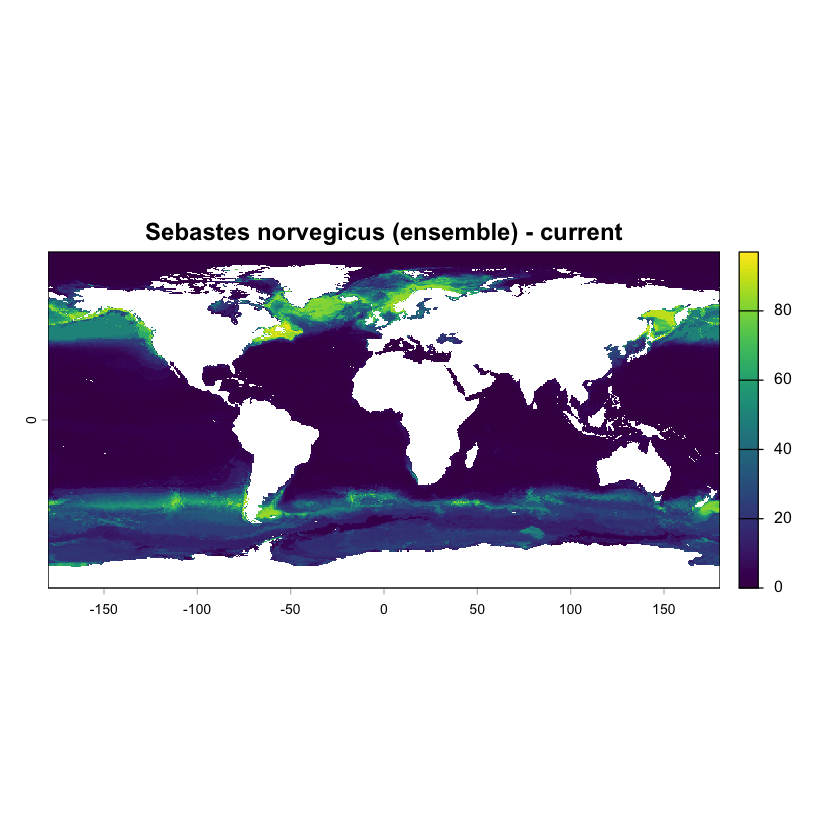

In [6]:
library(terra)

chosen_method <- best_method(sp_item$properties$methods)
asset_key <- glue("method={chosen_method}_scen=current_what=prediction")
pred_href <- s3_to_https(sp_item$assets[[asset_key]]$href)

pred <- rast(pred_href)
plot(pred[[1]], main = glue("{sp_item$properties$scientificName} ({chosen_method}) - current"))

Once you have the href for a given asset, you can download it directly with `download.file()` (or in bulk with the AWS CLI / `aws.s3`, as shown in the [OBIS SDM documentation](https://iobis.github.io/mpaeu_docs/datause.html)) instead of opening it remotely. Using the STAC catalogue this way lets you decide exactly which files to fetch for which species, without having to browse or sync the whole S3 bucket.